# Modeling Notebook — PubMed RCT 20k

**Dataset:** `armanc/pubmed-rct20k`  
**Task:** 5-class sentence-level classification (BACKGROUND / OBJECTIVE / METHODS / RESULTS / CONCLUSIONS)

**Models implemented:**
1. **LSTM Baseline** — Embedding → BiLSTM → Dropout → Linear classifier
2. **Transformer Fine-tune** — `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract` (or `distilbert-base-uncased`)

**Metrics reported:**  
Accuracy · Macro F1 · Per-class Precision/Recall/F1 · Confusion Matrix · Perplexity · Training curves

## 0. Setup & Configuration

In [1]:
# !pip install datasets transformers torch scikit-learn matplotlib seaborn tqdm

import os
import math
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

WORK_DIR = Path('.')
FIG_DIR = WORK_DIR / 'figures'
LOG_DIR = WORK_DIR / 'logs'
MODEL_DIR = WORK_DIR / 'models'
for d in [FIG_DIR, LOG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters (edit here) ──────────────────────────────────────────────
CFG = dict(
    # Data
    max_length     = 128,      # max tokens per sentence
    # LSTM
    vocab_min_freq = 2,        # min word frequency for LSTM vocab
    embed_dim      = 128,
    hidden_dim     = 256,
    n_lstm_layers  = 2,
    lstm_dropout   = 0.3,
    lstm_lr        = 1e-3,
    lstm_epochs    = 100,
    lstm_batch     = 128,
    # Transformer
    model_name     = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract',
    # Fallback if above is slow to download:
    # model_name   = 'distilbert-base-uncased',
    transf_lr      = 2e-5,
    transf_epochs  = 3,
    transf_batch   = 32,
    warmup_ratio   = 0.1,
    weight_decay   = 0.01,
    # Shared
    num_labels     = 5,
)

LABEL_ORDER = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
label2int = {label: idx for idx, label in enumerate(LABEL_ORDER)}
int2label = {idx: label for label, idx in label2int.items()}
print('Config loaded.')

/blue/bme6938/share/conda/pt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Config loaded.


## 1. Load & Prepare Data

In [2]:
ds = load_dataset('armanc/pubmed-rct20k')
print(ds)

print('Dataset label column type:', type(ds['train'][0]['label']).__name__)
print('Label map:', int2label)

train_texts  = ds['train']['text']
train_labels = [label2int[label.upper()] for label in ds['train']['label']]
val_texts    = ds['validation']['text']
val_labels   = [label2int[label.upper()] for label in ds['validation']['label']]
test_texts   = ds['test']['text']
test_labels  = [label2int[label.upper()] for label in ds['test']['label']]

print(f'Train: {len(train_texts):,} | Val: {len(val_texts):,} | Test: {len(test_texts):,}')

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 176642
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29672
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29578
    })
})
Dataset label column type: str
Label map: {0: 'BACKGROUND', 1: 'OBJECTIVE', 2: 'METHODS', 3: 'RESULTS', 4: 'CONCLUSIONS'}
Train: 176,642 | Val: 29,672 | Test: 29,578


In [3]:
# ── Compute class weights for imbalance handling ─────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(CFG['num_labels']),
    y=np.array(train_labels)
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print('Class weights:', {int2label[i]: f'{w:.3f}' for i, w in enumerate(class_weights)})

Class weights: {'BACKGROUND': '1.920', 'OBJECTIVE': '2.553', 'METHODS': '0.596', 'RESULTS': '0.610', 'CONCLUSIONS': '1.300'}


## 2. LSTM Baseline
### 2.1 Vocabulary & Tokenization

In [ ]:
import re

def lstm_tokenize(text):
    """Simple whitespace + punctuation tokenizer for LSTM."""
    text = text.lower()
    text = re.sub(r'([.,!?;:\-/\(\)\[\]{}\"\'])', r' \1 ', text)
    return text.split()

# Build vocabulary from training set
counter = Counter(tok for sent in train_texts for tok in lstm_tokenize(sent))
vocab_words = [w for w, c in counter.items() if c >= CFG['vocab_min_freq']]

PAD_IDX = 0
UNK_IDX = 1
word2idx = {w: i + 2 for i, w in enumerate(vocab_words)}
vocab_size = len(word2idx) + 2  # +2 for PAD and UNK

print(f'Vocabulary size (min_freq={CFG["vocab_min_freq"]}): {vocab_size:,}')

def encode(text, max_len=CFG['max_length']):
    """Encode text to padded/truncated integer sequence."""
    ids = [word2idx.get(t, UNK_IDX) for t in lstm_tokenize(text)][:max_len]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

In [ ]:
class SentenceDataset(TorchDataset):
    """PyTorch Dataset wrapping encoded text and labels."""
    def __init__(self, texts, labels, encoder_fn):
        self.x = [torch.tensor(encoder_fn(t), dtype=torch.long) for t in texts]
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

lstm_train_ds = SentenceDataset(train_texts, train_labels, encode)
lstm_val_ds   = SentenceDataset(val_texts,   val_labels,   encode)
lstm_test_ds  = SentenceDataset(test_texts,  test_labels,  encode)

lstm_train_loader = DataLoader(lstm_train_ds, batch_size=CFG['lstm_batch'], shuffle=True,  num_workers=2, pin_memory=True)
lstm_val_loader   = DataLoader(lstm_val_ds,   batch_size=CFG['lstm_batch'], shuffle=False, num_workers=2, pin_memory=True)
lstm_test_loader  = DataLoader(lstm_test_ds,  batch_size=CFG['lstm_batch'], shuffle=False, num_workers=2, pin_memory=True)
print('DataLoaders created.')

DataLoaders created.


### 2.2 BiLSTM Model Definition

In [ ]:
class BiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM text classifier.

    Architecture:
        Embedding → BiLSTM (n_layers) → mean pooling → Dropout → Linear

    Args:
        vocab_size (int): Vocabulary size including PAD and UNK tokens.
        embed_dim (int): Embedding dimension.
        hidden_dim (int): LSTM hidden state size (per direction).
        n_layers (int): Number of stacked LSTM layers.
        dropout (float): Dropout probability applied between layers and after pooling.
        num_classes (int): Number of output classes.
        pad_idx (int): Index of the padding token.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers,
                 dropout, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        """
        Args:
            x: LongTensor of shape (batch, seq_len)
        Returns:
            logits: FloatTensor of shape (batch, num_classes)
        """
        emb = self.dropout(self.embedding(x))        # (B, L, E)
        out, _ = self.lstm(emb)                      # (B, L, 2*H)
        # Mean pooling over non-padding positions
        mask = (x != PAD_IDX).unsqueeze(-1).float()  # (B, L, 1)
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        logits = self.fc(self.dropout(pooled))       # (B, C)
        return logits


lstm_model = BiLSTMClassifier(
    vocab_size  = vocab_size,
    embed_dim   = CFG['embed_dim'],
    hidden_dim  = CFG['hidden_dim'],
    n_layers    = CFG['n_lstm_layers'],
    dropout     = CFG['lstm_dropout'],
    num_classes = CFG['num_labels'],
    pad_idx     = PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(lstm_model)
print(f'\nTrainable parameters: {total_params:,}')

# Notebook-safe data loading: avoid multiprocessing workers in Jupyter.
lstm_train_loader = DataLoader(
    lstm_train_ds,
    batch_size=CFG['lstm_batch'],
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
lstm_val_loader = DataLoader(
    lstm_val_ds,
    batch_size=CFG['lstm_batch'],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
lstm_test_loader = DataLoader(
    lstm_test_ds,
    batch_size=CFG['lstm_batch'],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

BiLSTMClassifier(
  (embedding): Embedding(34122, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=5, bias=True)
)

Trainable parameters: 6,737,669


### 2.3 Training Loop

In [ ]:
def compute_perplexity(avg_cross_entropy_loss: float) -> float:
    """
    Compute perplexity from average cross-entropy loss.

    For classification, perplexity = exp(CE_loss).
    Interpretation: lower is better; perfect predictions → perplexity = 1.
    Random baseline for 5-class problem → perplexity ≈ 5.

    Args:
        avg_cross_entropy_loss: Mean cross-entropy loss over dataset.
    Returns:
        Perplexity value.
    """
    return math.exp(avg_cross_entropy_loss)


def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    """Run one training epoch. Returns (avg_loss, accuracy, perplexity)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in tqdm(loader, desc='  Train', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    return avg_loss, correct / total, compute_perplexity(avg_loss)


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluate model. Returns (avg_loss, accuracy, perplexity, all_preds, all_labels)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for x, y in tqdm(loader, desc='  Eval ', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / total
    return avg_loss, correct / total, compute_perplexity(avg_loss), all_preds, all_labels


print('Training utilities defined.')

Training utilities defined.


In [ ]:
lstm_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=CFG['lstm_lr'])
lstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    lstm_optimizer, mode='min', patience=2, factor=0.5
)

lstm_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
                'train_ppl': [], 'val_ppl': []}
best_val_loss = float('inf')
LSTM_CKPT = MODEL_DIR / 'lstm_best.pt'

print(f'Training BiLSTM for {CFG["lstm_epochs"]} epochs...\n')

for epoch in range(1, CFG['lstm_epochs'] + 1):
    tr_loss, tr_acc, tr_ppl = train_epoch(lstm_model, lstm_train_loader, lstm_optimizer, lstm_criterion)
    vl_loss, vl_acc, vl_ppl, _, _ = evaluate(lstm_model, lstm_val_loader, lstm_criterion)

    lstm_scheduler.step(vl_loss)

    lstm_history['train_loss'].append(tr_loss)
    lstm_history['val_loss'].append(vl_loss)
    lstm_history['train_acc'].append(tr_acc)
    lstm_history['val_acc'].append(vl_acc)
    lstm_history['train_ppl'].append(tr_ppl)
    lstm_history['val_ppl'].append(vl_ppl)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(lstm_model.state_dict(), LSTM_CKPT)

    print(f'Epoch {epoch:02d}/{CFG["lstm_epochs"]} | '
          f'Train Loss: {tr_loss:.4f} (PPL {tr_ppl:.2f}) Acc {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} (PPL {vl_ppl:.2f}) Acc {vl_acc:.4f}')

print(f'\nBest val loss: {best_val_loss:.4f} → checkpoint saved to {LSTM_CKPT}')

Training BiLSTM for 10 epochs...



Epoch 01/10 | Train Loss: 0.7612 (PPL 2.14) Acc 0.7478 | Val Loss: 0.6212 (PPL 1.86) Acc 0.8134


Epoch 02/10 | Train Loss: 0.6014 (PPL 1.82) Acc 0.8148 | Val Loss: 0.5510 (PPL 1.73) Acc 0.8346


Epoch 03/10 | Train Loss: 0.5486 (PPL 1.73) Acc 0.8326 | Val Loss: 0.5438 (PPL 1.72) Acc 0.8393


Epoch 04/10 | Train Loss: 0.5071 (PPL 1.66) Acc 0.8464 | Val Loss: 0.5442 (PPL 1.72) Acc 0.8405


...

Epoch 06/10 | Train Loss: 0.4376 (PPL 1.55) Acc 0.8666 | Val Loss: 0.5794 (PPL 1.78) Acc 0.8475


Epoch 07/10 | Train Loss: 0.3824 (PPL 1.47) Acc 0.8833 | Val Loss: 0.5716 (PPL 1.77) Acc 0.8441


Epoch 08/10 | Train Loss: 0.3527 (PPL 1.42) Acc 0.8913 | Val Loss: 0.6217 (PPL 1.86) Acc 0.8429


Epoch 09/10 | Train Loss: 0.3295 (PPL 1.39) Acc 0.8979 | Val Loss: 0.6151 (PPL 1.85) Acc 0.8405


Epoch 10/10 | Train Loss: 0.2963 (PPL 1.34) Acc 0.9065 | Val Loss: 0.6660 (PPL 1.95) Acc 0.8421

Best val loss: 0.5438 → checkpoint saved to models/lstm_best.pt


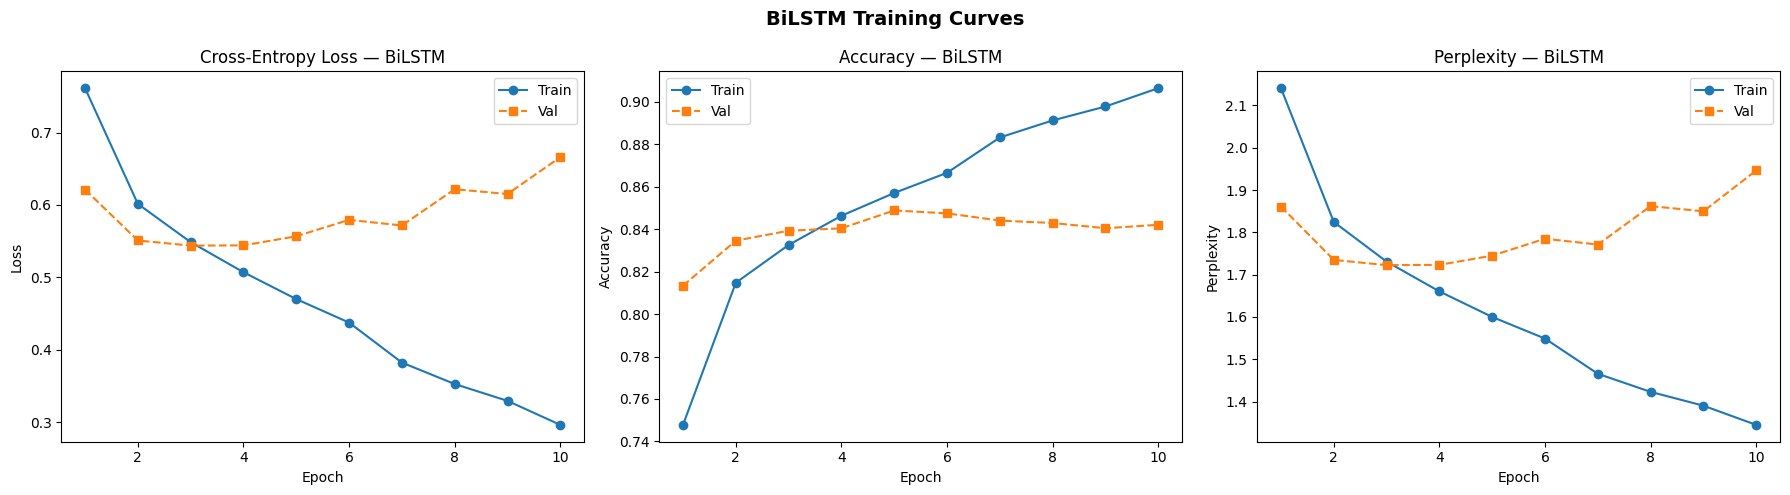

Saved: lstm_training_curves.png


In [ ]:
# ── Plot LSTM training curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x = range(1, CFG['lstm_epochs'] + 1)

ax = axes[0]
ax.plot(epochs_x, lstm_history['train_loss'], 'o-', label='Train')
ax.plot(epochs_x, lstm_history['val_loss'],   's--', label='Val')
ax.set_title('Cross-Entropy Loss — BiLSTM'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()

ax = axes[1]
ax.plot(epochs_x, lstm_history['train_acc'], 'o-', label='Train')
ax.plot(epochs_x, lstm_history['val_acc'],   's--', label='Val')
ax.set_title('Accuracy — BiLSTM'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.legend()

ax = axes[2]
ax.plot(epochs_x, lstm_history['train_ppl'], 'o-', label='Train')
ax.plot(epochs_x, lstm_history['val_ppl'],   's--', label='Val')
ax.set_title('Perplexity — BiLSTM'); ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity'); ax.legend()

plt.suptitle('BiLSTM Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lstm_training_curves.png')

### 2.4 LSTM Test Evaluation

In [ ]:
# Load best checkpoint
lstm_model.load_state_dict(torch.load(LSTM_CKPT, map_location=DEVICE))

test_loss, test_acc, test_ppl, lstm_preds, lstm_true = evaluate(
    lstm_model, lstm_test_loader, lstm_criterion
)

lstm_macro_f1  = f1_score(lstm_true, lstm_preds, average='macro')
lstm_weighted_f1 = f1_score(lstm_true, lstm_preds, average='weighted')

print('=== BiLSTM — Test Set Results ===')
print(f'  Loss:        {test_loss:.4f}')
print(f'  Perplexity:  {test_ppl:.4f}')
print(f'  Accuracy:    {test_acc:.4f}')
print(f'  Macro F1:    {lstm_macro_f1:.4f}')
print(f'  Weighted F1: {lstm_weighted_f1:.4f}')
print()
print(classification_report(lstm_true, lstm_preds, target_names=LABEL_ORDER, digits=4))

  Eval :   7%|▋         | 16/232 [00:00<00:01, 155.61it/s]

=== BiLSTM — Test Set Results ===
  Loss:        0.5655
  Perplexity:  1.7603
  Accuracy:    0.8312
  Macro F1:    0.7699
  Weighted F1: 0.8330

              precision    recall  f1-score   support

  BACKGROUND     0.5889    0.6913    0.6360      3077
   OBJECTIVE     0.6508    0.6198    0.6349      2333
     METHODS     0.9118    0.9058    0.9088      9884
     RESULTS     0.9052    0.8777    0.8912      9713
 CONCLUSIONS     0.7843    0.7734    0.7788      4571

    accuracy                         0.8312     29578
   macro avg     0.7682    0.7736    0.7699     29578
weighted avg     0.8357    0.8312    0.8330     29578



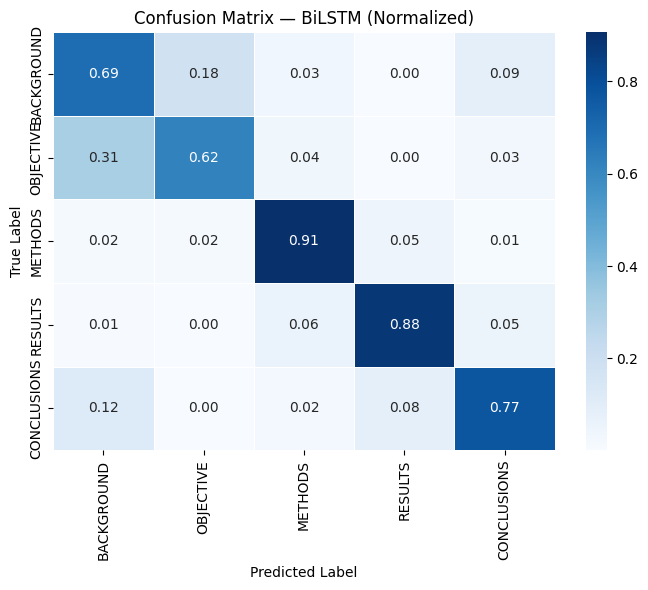

Saved: figures/lstm_confusion_matrix.png


In [ ]:
def plot_confusion_matrix(y_true, y_pred, label_names, title, save_path):
    """Plot and save a normalized confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_confusion_matrix(lstm_true, lstm_preds, LABEL_ORDER,
                      'Confusion Matrix — BiLSTM (Normalized)', FIG_DIR / 'lstm_confusion_matrix.png')

## 3. Transformer Fine-tuning (PubMedBERT / DistilBERT)
### 3.1 Tokenization & Dataset

In [4]:
transf_tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
print(f'Loaded tokenizer: {CFG["model_name"]}')
print(f'Vocab size: {transf_tokenizer.vocab_size:,}')

# Quick sanity check
sample_enc = transf_tokenizer(
    'Patients were randomized to receive treatment.',
    max_length=CFG['max_length'], padding='max_length', truncation=True
)
print('Sample input_ids:', sample_enc['input_ids'][:10], '...')

Loaded tokenizer: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Vocab size: 28,895
Sample input_ids: [2, 1808, 1748, 4384, 1701, 6696, 2015, 17, 3, 0] ...


In [5]:
class TransformerDataset(TorchDataset):
    """
    HuggingFace tokenizer-based dataset for sequence classification.

    Args:
        texts: List of raw text strings.
        labels: List of integer labels.
        tokenizer: HuggingFace tokenizer instance.
        max_length: Maximum sequence length (padding + truncation).
    """
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        # Tokenize on-the-fly to avoid loading all 235k samples into memory
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {k: v[0] for k, v in encoding.items()}  # Remove batch dimension added by return_tensors
        item['labels'] = torch.tensor(label, dtype=torch.long)
        return item


transf_train_ds = TransformerDataset(train_texts, train_labels, transf_tokenizer, CFG['max_length'])
transf_val_ds   = TransformerDataset(val_texts,   val_labels,   transf_tokenizer, CFG['max_length'])
transf_test_ds  = TransformerDataset(test_texts,  test_labels,  transf_tokenizer, CFG['max_length'])

# Notebook-safe data loading: avoid multiprocessing workers in Jupyter.
transf_train_loader = DataLoader(
    transf_train_ds,
    batch_size=CFG['transf_batch'],
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
transf_val_loader = DataLoader(
    transf_val_ds,
    batch_size=CFG['transf_batch'],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
transf_test_loader = DataLoader(
    transf_test_ds,
    batch_size=CFG['transf_batch'],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
print(f'Dataset sizes — Train: {len(transf_train_ds):,} | Val: {len(transf_val_ds):,} | Test: {len(transf_test_ds):,}')

Dataset sizes — Train: 176,642 | Val: 29,672 | Test: 29,578


### 3.2 Load Pretrained Model

In [ ]:
transf_model = AutoModelForSequenceClassification.from_pretrained(
    CFG['model_name'],
    num_labels=CFG['num_labels'],
    ignore_mismatched_sizes=True
).to(DEVICE)

total_params = sum(p.numel() for p in transf_model.parameters())
trainable    = sum(p.numel() for p in transf_model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,} | Trainable: {trainable:,}')

### 3.3 Fine-tuning Loop

In [ ]:
# Optimizer with weight decay (no decay on bias/LayerNorm)
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in transf_model.named_parameters() if not any(nd in n for nd in no_decay)],
     'weight_decay': CFG['weight_decay']},
    {'params': [p for n, p in transf_model.named_parameters() if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
transf_optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=CFG['transf_lr'])

total_steps   = len(transf_train_loader) * CFG['transf_epochs']
warmup_steps  = int(total_steps * CFG['warmup_ratio'])
transf_scheduler = get_linear_schedule_with_warmup(
    transf_optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

transf_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f'Total steps: {total_steps:,} | Warmup steps: {warmup_steps:,}')

In [ ]:
def train_epoch_transf(model, loader, optimizer, scheduler, criterion):
    """One fine-tuning epoch for a HuggingFace sequence classifier."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in tqdm(loader, desc='  Train', leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch.get('token_type_ids', None)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        logits = outputs.logits
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    return avg_loss, correct / total, compute_perplexity(avg_loss)


@torch.no_grad()
def evaluate_transf(model, loader, criterion):
    """Evaluate a HuggingFace sequence classifier."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='  Eval ', leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch.get('token_type_ids', None)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        logits = outputs.logits
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    return avg_loss, correct / total, compute_perplexity(avg_loss), all_preds, all_labels


print('Transformer training utilities defined.')

In [ ]:
transf_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
                  'train_ppl': [], 'val_ppl': []}
best_val_loss_transf = float('inf')
TRANSF_CKPT = MODEL_DIR / 'transf_best.pt'

print(f'Fine-tuning {CFG["model_name"]} for {CFG["transf_epochs"]} epochs...\n')

for epoch in range(1, CFG['transf_epochs'] + 1):
    tr_loss, tr_acc, tr_ppl = train_epoch_transf(
        transf_model, transf_train_loader, transf_optimizer, transf_scheduler, transf_criterion
    )
    vl_loss, vl_acc, vl_ppl, _, _ = evaluate_transf(
        transf_model, transf_val_loader, transf_criterion
    )

    transf_history['train_loss'].append(tr_loss)
    transf_history['val_loss'].append(vl_loss)
    transf_history['train_acc'].append(tr_acc)
    transf_history['val_acc'].append(vl_acc)
    transf_history['train_ppl'].append(tr_ppl)
    transf_history['val_ppl'].append(vl_ppl)

    if vl_loss < best_val_loss_transf:
        best_val_loss_transf = vl_loss
        torch.save(transf_model.state_dict(), TRANSF_CKPT)

    print(f'Epoch {epoch:02d}/{CFG["transf_epochs"]} | '
          f'Train Loss: {tr_loss:.4f} (PPL {tr_ppl:.2f}) Acc {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} (PPL {vl_ppl:.2f}) Acc {vl_acc:.4f}')

print(f'\nBest val loss: {best_val_loss_transf:.4f} → checkpoint saved to {TRANSF_CKPT}')

In [ ]:
# ── Transformer training curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x = range(1, CFG['transf_epochs'] + 1)

ax = axes[0]
ax.plot(epochs_x, transf_history['train_loss'], 'o-', label='Train')
ax.plot(epochs_x, transf_history['val_loss'],   's--', label='Val')
ax.set_title(f'Loss — {CFG["model_name"].split("/")[-1]}'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()

ax = axes[1]
ax.plot(epochs_x, transf_history['train_acc'], 'o-', label='Train')
ax.plot(epochs_x, transf_history['val_acc'],   's--', label='Val')
ax.set_title('Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.legend()

ax = axes[2]
ax.plot(epochs_x, transf_history['train_ppl'], 'o-', label='Train')
ax.plot(epochs_x, transf_history['val_ppl'],   's--', label='Val')
ax.set_title('Perplexity'); ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity'); ax.legend()

plt.suptitle(f'Transformer Fine-tuning Curves ({CFG["model_name"].split("/")[-1]})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'transf_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: transf_training_curves.png')

### 3.4 Transformer Test Evaluation

In [ ]:
transf_model.load_state_dict(torch.load(TRANSF_CKPT, map_location=DEVICE))

tt_loss, tt_acc, tt_ppl, transf_preds, transf_true = evaluate_transf(
    transf_model, transf_test_loader, transf_criterion
)

transf_macro_f1    = f1_score(transf_true, transf_preds, average='macro')
transf_weighted_f1 = f1_score(transf_true, transf_preds, average='weighted')

print(f'=== {CFG["model_name"].split("/")[-1]} — Test Set Results ===')
print(f'  Loss:        {tt_loss:.4f}')
print(f'  Perplexity:  {tt_ppl:.4f}')
print(f'  Accuracy:    {tt_acc:.4f}')
print(f'  Macro F1:    {transf_macro_f1:.4f}')
print(f'  Weighted F1: {transf_weighted_f1:.4f}')
print()
print(classification_report(transf_true, transf_preds, target_names=LABEL_ORDER, digits=4))

In [ ]:
plot_confusion_matrix(transf_true, transf_preds, LABEL_ORDER,
                      f'Confusion Matrix — {CFG["model_name"].split("/")[-1]} (Normalized)',
                      FIG_DIR / 'transf_confusion_matrix.png')

## 4. Model Comparison

In [ ]:
# ── Summary comparison table ─────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

def model_summary(name, preds, true, loss, ppl):
    return {
        'Model'       : name,
        'Test Loss'   : round(loss, 4),
        'Perplexity'  : round(ppl, 4),
        'Accuracy'    : round(accuracy_score(true, preds), 4),
        'Macro F1'    : round(f1_score(true, preds, average='macro'), 4),
        'Macro Prec.' : round(precision_score(true, preds, average='macro'), 4),
        'Macro Rec.'  : round(recall_score(true, preds, average='macro'), 4),
        'Weighted F1' : round(f1_score(true, preds, average='weighted'), 4),
    }

results_df = pd.DataFrame([
    model_summary('BiLSTM (baseline)', lstm_preds, lstm_true, test_loss, test_ppl),
    model_summary(CFG['model_name'].split('/')[-1], transf_preds, transf_true, tt_loss, tt_ppl),
])
results_df = results_df.set_index('Model')
print('\n=== MODEL COMPARISON ===')
print(results_df.to_string())

In [ ]:
# ── Bar chart comparison ─────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Macro F1', 'Weighted F1']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_df[metric].values
    models = results_df.index.tolist()
    bars = ax.bar(models, vals, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Comparison — PubMed RCT 20k Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

In [ ]:
# ── Per-class F1 comparison ──────────────────────────────────────────────────
lstm_per_class    = f1_score(lstm_true,   lstm_preds,   average=None, labels=list(range(5)))
transf_per_class  = f1_score(transf_true, transf_preds, average=None, labels=list(range(5)))

x = np.arange(len(LABEL_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, lstm_per_class,   width, label='BiLSTM',     color='#4C72B0', edgecolor='white')
ax.bar(x + width/2, transf_per_class, width, label=CFG['model_name'].split('/')[-1],
       color='#DD8452', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(LABEL_ORDER, rotation=10, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 Score — BiLSTM vs Transformer (Test Set)')
ax.legend()
for xi, (v1, v2) in zip(x, zip(lstm_per_class, transf_per_class)):
    ax.text(xi - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=8)
    ax.text(xi + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_f1.png')

In [ ]:
# ── Perplexity comparison ────────────────────────────────────────────────────
ppl_data = {
    'Model': ['BiLSTM', CFG['model_name'].split('/')[-1]],
    'Train PPL (final epoch)': [
        lstm_history['train_ppl'][-1],
        transf_history['train_ppl'][-1]
    ],
    'Val PPL (best epoch)': [
        min(lstm_history['val_ppl']),
        min(transf_history['val_ppl'])
    ],
    'Test PPL': [test_ppl, tt_ppl]
}
ppl_df = pd.DataFrame(ppl_data).set_index('Model')
print('\n=== PERPLEXITY SUMMARY ===')
print('(Random 5-class baseline perplexity = 5.00)')
print(ppl_df.round(4).to_string())

## 5. Error Analysis

In [ ]:
# ── Most common error pairs ──────────────────────────────────────────────────
def get_error_pairs(true, preds, label_names):
    """Return a sorted DataFrame of (true, predicted) confusion pairs."""
    errors = [(label_names[t], label_names[p]) for t, p in zip(true, preds) if t != p]
    pair_counts = Counter(errors)
    df = pd.DataFrame([
        {'True Label': t, 'Predicted Label': p, 'Count': c}
        for (t, p), c in pair_counts.most_common()
    ])
    return df

print('=== BiLSTM — Top Error Pairs ===')
lstm_errors = get_error_pairs(lstm_true, lstm_preds, LABEL_ORDER)
print(lstm_errors.head(10).to_string(index=False))

print(f'\n=== {CFG["model_name"].split("/")[-1]} — Top Error Pairs ===')
transf_errors = get_error_pairs(transf_true, transf_preds, LABEL_ORDER)
print(transf_errors.head(10).to_string(index=False))

In [ ]:
# ── Show example misclassified sentences (Transformer) ──────────────────────
print('=== Example Misclassifications (Transformer) ===\n')

test_df_err = pd.DataFrame({
    'text': test_texts,
    'true': [LABEL_ORDER[l] for l in transf_true],
    'pred': [LABEL_ORDER[p] for p in transf_preds]
})
errors_df = test_df_err[test_df_err['true'] != test_df_err['pred']]

# Show 2 examples from each major error type
top_pairs = transf_errors.head(5)[['True Label', 'Predicted Label']].values.tolist()
for true_l, pred_l in top_pairs:
    subset = errors_df[(errors_df['true'] == true_l) & (errors_df['pred'] == pred_l)]
    if len(subset) == 0:
        continue
    print(f'True: {true_l} → Predicted: {pred_l} ({len(subset)} errors)')
    for _, row in subset.sample(min(2, len(subset)), random_state=42).iterrows():
        print(f'  → "{row["text"][:140]}"')
    print()

In [ ]:
# ── Error rate by sentence length (Transformer) ──────────────────────────────
test_df_err['n_words'] = test_df_err['text'].apply(lambda x: len(x.split()))
test_df_err['error']   = (test_df_err['true'] != test_df_err['pred']).astype(int)

bins = [0, 10, 20, 30, 40, 60, 200]
labels_bins = ['0-10', '11-20', '21-30', '31-40', '41-60', '61+']
test_df_err['length_bin'] = pd.cut(test_df_err['n_words'], bins=bins, labels=labels_bins)

err_by_len = test_df_err.groupby('length_bin')['error'].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(err_by_len['length_bin'].astype(str), err_by_len['error'] * 100, color='#C44E52', edgecolor='white')
ax.set_xlabel('Sentence Length (words)')
ax.set_ylabel('Error Rate (%)')
ax.set_title(f'Error Rate by Sentence Length — {CFG["model_name"].split("/")[-1]}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'error_by_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_by_length.png')

## 6. Qualitative Inspection — Correct Predictions

In [ ]:
correct_df = test_df_err[test_df_err['error'] == 0]
print('=== Correctly Classified Examples (2 per class) ===\n')
for label in LABEL_ORDER:
    subset = correct_df[correct_df['true'] == label]
    if len(subset) == 0:
        continue
    print(f'[{label}]')
    for _, row in subset.sample(min(2, len(subset)), random_state=42).iterrows():
        print(f'  ✓ "{row["text"][:150]}"')
    print()

## 7. Final Results Summary

In [ ]:
print('='*80)
print('FINAL RESULTS SUMMARY — PubMed RCT 20k')
print('='*80)
print(results_df.to_string())
print('\n--- Perplexity ---')
print(ppl_df.round(4).to_string())
print('\nNote: Random 5-class baseline perplexity = 5.00 | Perfect classifier = 1.00')

print('\n--- All Saved Figures ---')
for fname in ['lstm_training_curves.png', 'lstm_confusion_matrix.png',
              'transf_training_curves.png', 'transf_confusion_matrix.png',
              'model_comparison.png', 'per_class_f1.png', 'error_by_length.png']】【：】【“】【    print(f'  {FIG_DIR / fname}')

In [ ]:
# ── Side-by-side confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (preds, true, title) in zip(axes, [
    (lstm_preds,   lstm_true,   'BiLSTM'),
    (transf_preds, transf_true, CFG['model_name'].split('/')[-1])
]):
    cm = confusion_matrix(true, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Normalized Confusion Matrix\n{title}', fontweight='bold')

plt.suptitle('Model Comparison — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_comparison.png')

---
## End of Modeling Notebook

### Summary of outputs:
| File | Description |
|---|---|
| `lstm_best.pt` | Best BiLSTM checkpoint (by val loss) |
| `transf_best.pt` | Best transformer checkpoint (by val loss) |
| `lstm_training_curves.png` | Loss / Accuracy / Perplexity curves — LSTM |
| `transf_training_curves.png` | Loss / Accuracy / Perplexity curves — Transformer |
| `lstm_confusion_matrix.png` | Normalized CM — LSTM |
| `transf_confusion_matrix.png` | Normalized CM — Transformer |
| `confusion_matrices_comparison.png` | Side-by-side CMs |
| `model_comparison.png` | Accuracy / Macro F1 / Weighted F1 bar chart |
| `per_class_f1.png` | Per-class F1 comparison |
| `error_by_length.png` | Transformer error rate by sentence length |

Next steps:
- GitHub README & repository
- Report (4+ pages)
- Presentation/demo